# Import

In [45]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load Data

In [47]:
df = pd.read_csv(os.path.abspath('data/country_wise_latest.csv'))
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [49]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [50]:
df.shape

(187, 15)

In [51]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [57]:
df.duplicated(subset=["Country/Region"]).sum()

np.int64(0)

In [60]:
# Total Cases by Country
df.groupby("Country/Region")['Confirmed'].max().sort_values(ascending=False)

Country/Region
US                       4290259
Brazil                   2442375
India                    1480073
Russia                    816680
South Africa              452529
                          ...   
Dominica                      18
Saint Kitts and Nevis         17
Greenland                     14
Holy See                      12
Western Sahara                10
Name: Confirmed, Length: 187, dtype: int64

In [65]:
# To 10 Countries by Deaths
df.groupby('Country/Region')['Deaths'].max().nlargest(10)

Country/Region
US                148011
Brazil             87618
United Kingdom     45844
Mexico             44022
Italy              35112
India              33408
France             30212
Spain              28432
Peru               18418
Iran               15912
Name: Deaths, dtype: int64

In [68]:
# Death Rate per Country
death_rate = df.groupby('Country/Region').agg({
    'Confirmed': 'max',
    'Deaths': 'max'
})

death_rate['Death_Rate'] = death_rate['Deaths'] / death_rate['Confirmed']
death_rate.sort_values('Death_Rate', ascending=False)

,Confirmed,Deaths,Death_Rate
Country/Region,,,
Yemen,1691,483,0.285630
United Kingdom,301708,45844,0.151948
Belgium,66428,9822,0.147859
Italy,246286,35112,0.142566
France,220352,30212,0.137108
...,...,...,...
Seychelles,114,0,0.000000
Saint Vincent and the Grenadines,52,0,0.000000
Saint Kitts and Nevis,17,0,0.000000


In [74]:
# Country-wise Peak
peak = df.loc[df.groupby('Country/Region')['Confirmed'].idxmax()]
peak

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,Eastern Mediterranean
183,Western Sahara,10,1,8,1,0,0,0,10.00,80.00,12.50,10,0,0.00,Africa
184,Yemen,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,Eastern Mediterranean
185,Zambia,4552,140,2815,1597,71,1,465,3.08,61.84,4.97,3326,1226,36.86,Africa


# Visualization

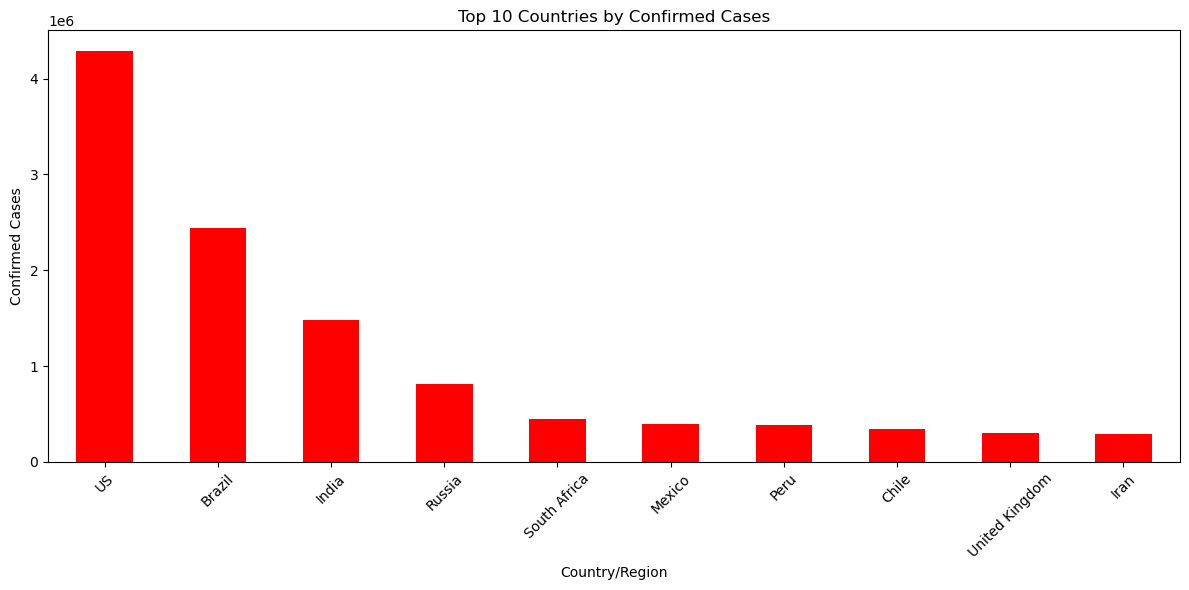

<Figure size 640x480 with 0 Axes>

In [88]:
top_confirmed = df.sort_values(by='Confirmed', ascending=False).head(10)

top_confirmed.plot(
    figsize=(12, 6),
    x='Country/Region',
    y='Confirmed',
    kind='bar',
    color='red',
    legend=False
)

plt.title("Top 10 Countries by Confirmed Cases")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(os.path.abspath("img/top_confirmed.png"))

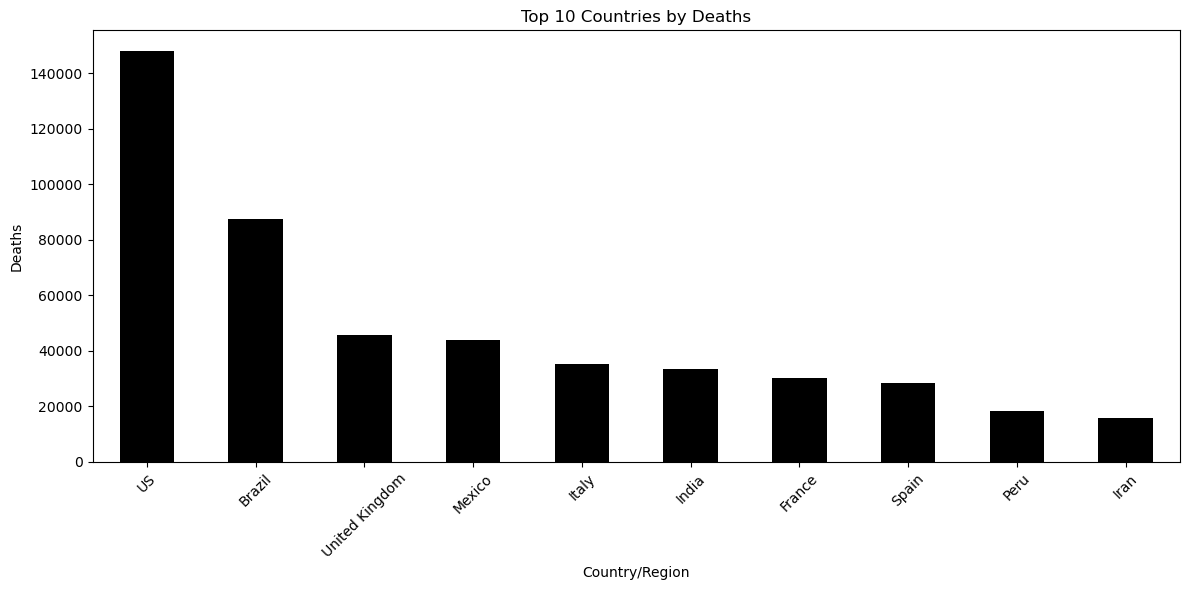

<Figure size 640x480 with 0 Axes>

In [89]:
top_deaths = df.sort_values(by='Deaths', ascending=False).head(10)

top_deaths.plot(
    figsize=(12, 6),
    x='Country/Region',
    y='Deaths',
    kind='bar',
    color='black',
    legend=False
)

plt.title("Top 10 Countries by Deaths")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(os.path.abspath("img/top_deaths.png"))

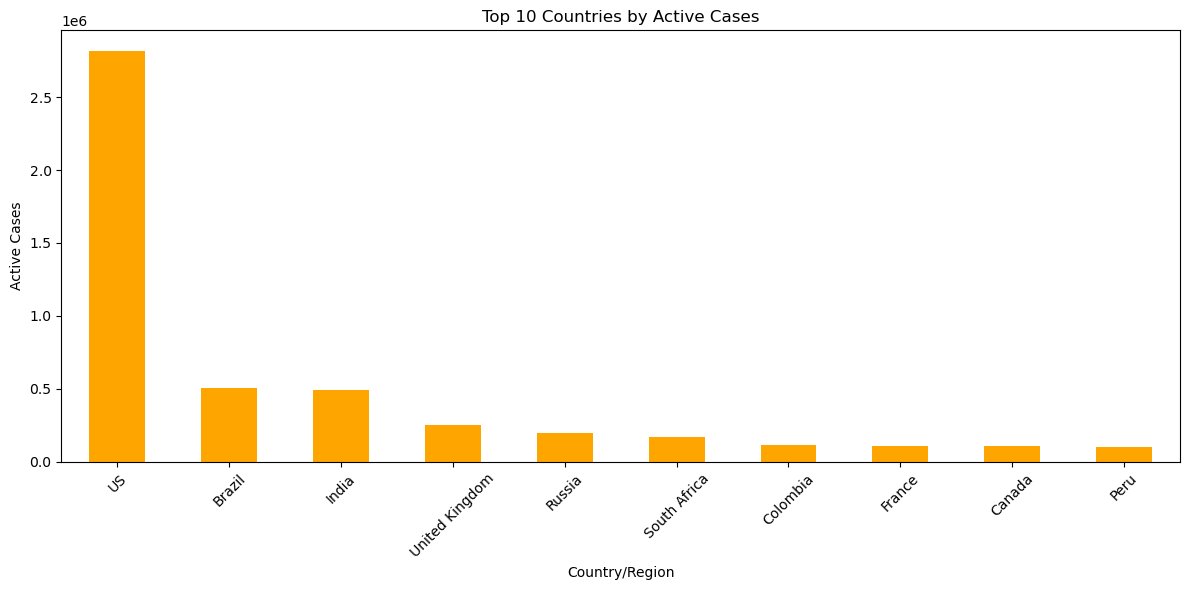

<Figure size 640x480 with 0 Axes>

In [92]:
top_active = df.sort_values(by='Active', ascending=False).head(10)

top_active.plot(
    figsize=(12, 6),
    x='Country/Region',
    y='Active',
    kind='bar',
    color='orange',
    legend=False
)

plt.title("Top 10 Countries by Active Cases")
plt.ylabel("Active Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(os.path.abspath("img/top_active.png"))

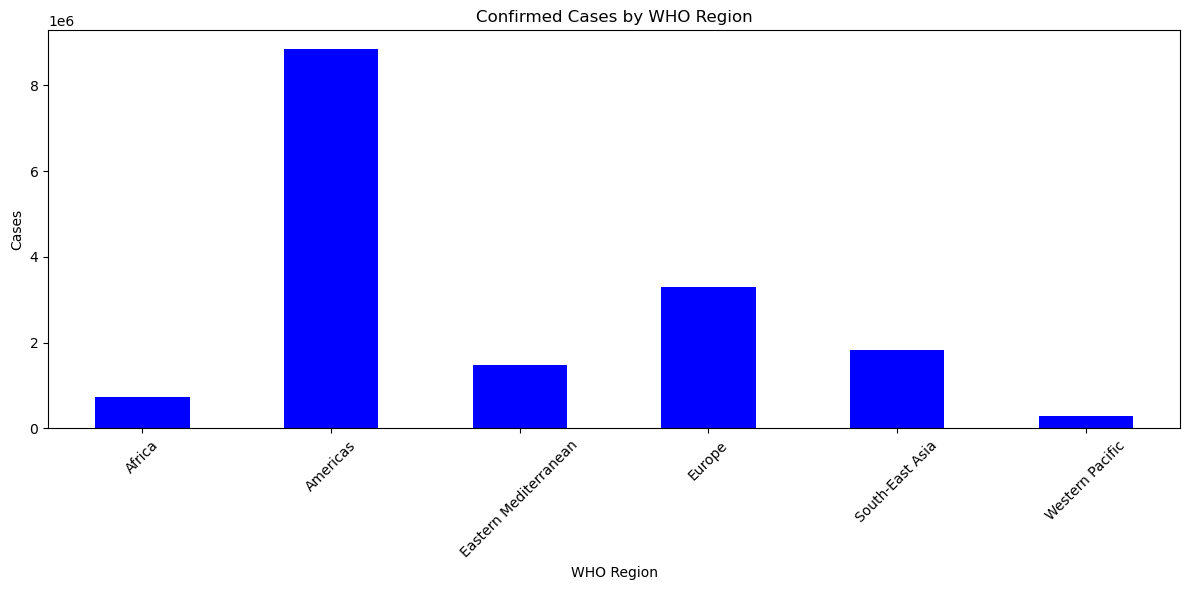

<Figure size 640x480 with 0 Axes>

In [94]:
region_cases = df.groupby('WHO Region')['Confirmed'].sum()

region_cases.plot(figsize=(12, 6), kind='bar', color='blue')

plt.title("Confirmed Cases by WHO Region")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(os.path.abspath("img/region_cases.png"))

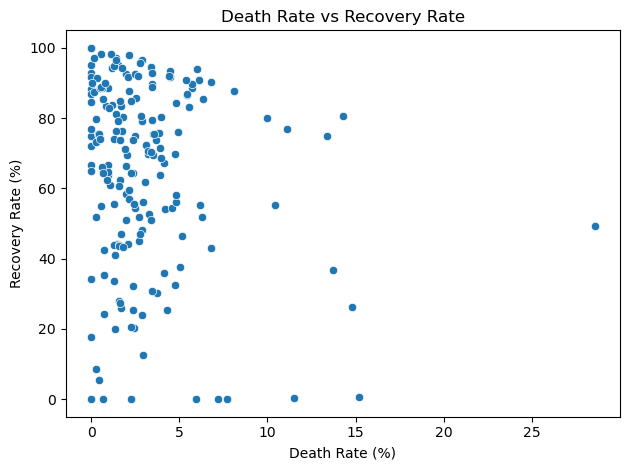

<Figure size 640x480 with 0 Axes>

In [97]:
import seaborn as sns

sns.scatterplot(
    x='Deaths / 100 Cases',
    y='Recovered / 100 Cases',
    data=df
)

plt.title("Death Rate vs Recovery Rate")
plt.xlabel("Death Rate (%)")
plt.ylabel("Recovery Rate (%)")
plt.tight_layout()
plt.show()
plt.savefig(os.path.abspath("img/death_recovery_rate.png"))

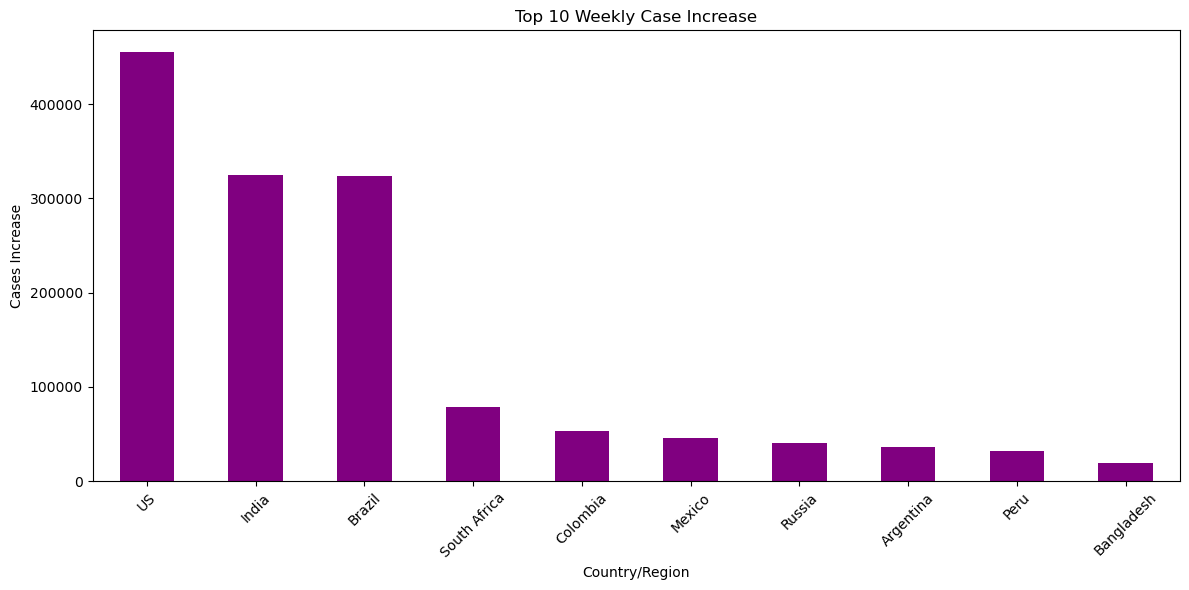

<Figure size 640x480 with 0 Axes>

In [98]:
top_growth = df.sort_values(by='1 week change', ascending=False).head(10)

top_growth.plot(
    figsize=(12, 6),
    x='Country/Region',
    y='1 week change',
    kind='bar',
    color='purple',
    legend=False
)

plt.title("Top 10 Weekly Case Increase")
plt.ylabel("Cases Increase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(os.path.abspath("img/top_growth.png"))

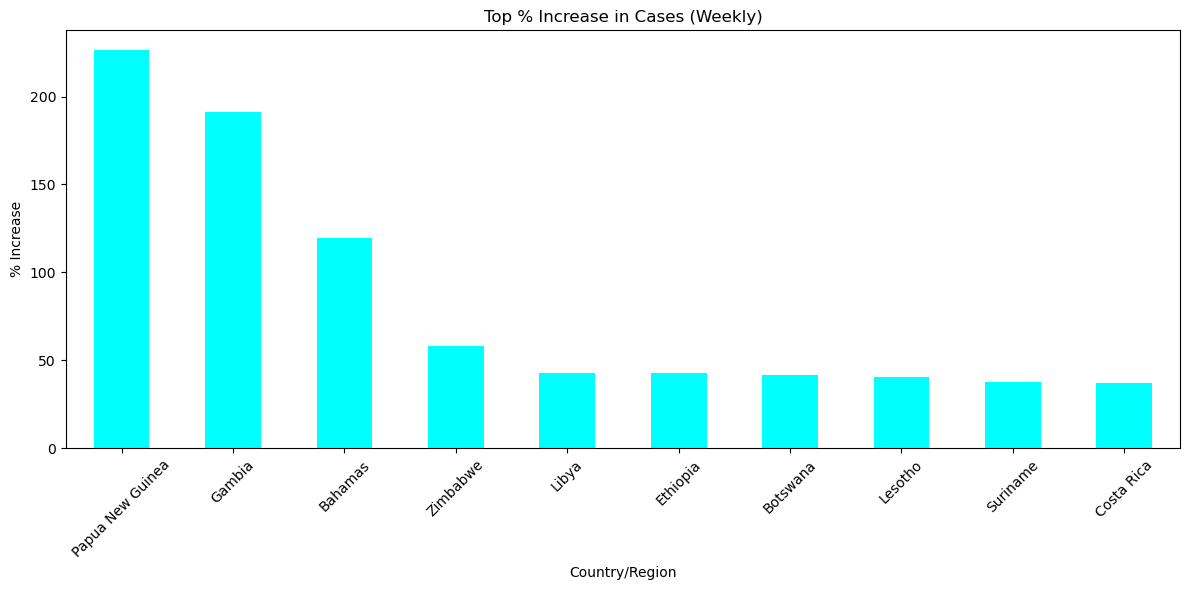

In [99]:
top_percent = df.sort_values(by='1 week % increase', ascending=False).head(10)

top_percent.plot(
    figsize=(12, 6),
    x='Country/Region',
    y='1 week % increase',
    kind='bar',
    color='cyan',
    legend=False
)

plt.title("Top % Increase in Cases (Weekly)")
plt.ylabel("% Increase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

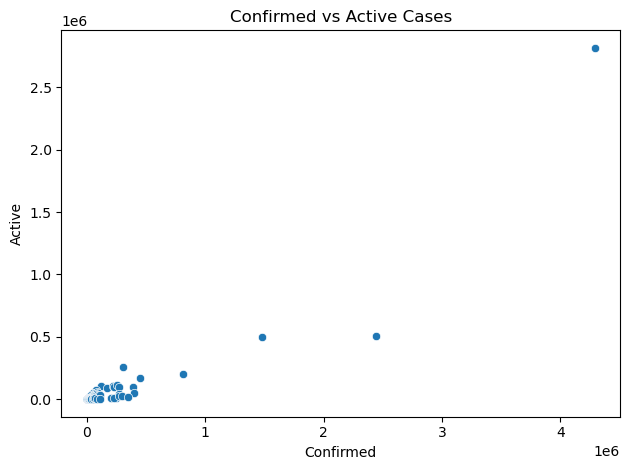

In [104]:
sns.scatterplot(
    x='Confirmed',
    y='Active',
    data=df
)

plt.title("Confirmed vs Active Cases")
plt.xlabel("Confirmed")
plt.ylabel("Active")
plt.tight_layout()
plt.show()

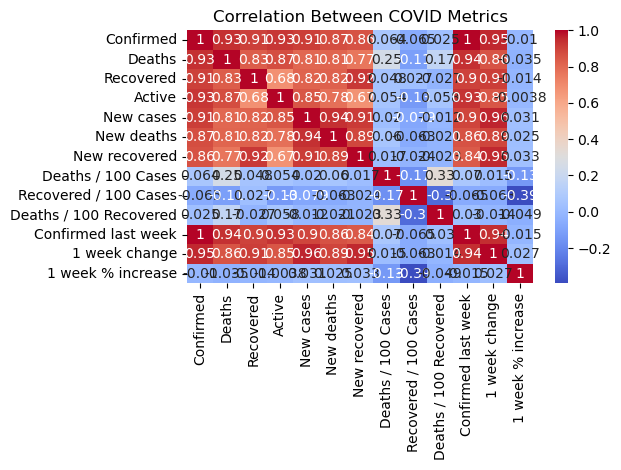

In [105]:
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.figure(f)
plt.title("Correlation Between COVID Metrics")
plt.tight_layout()
plt.show()